## **Задание 1** (4.18 - параметрический маятник)

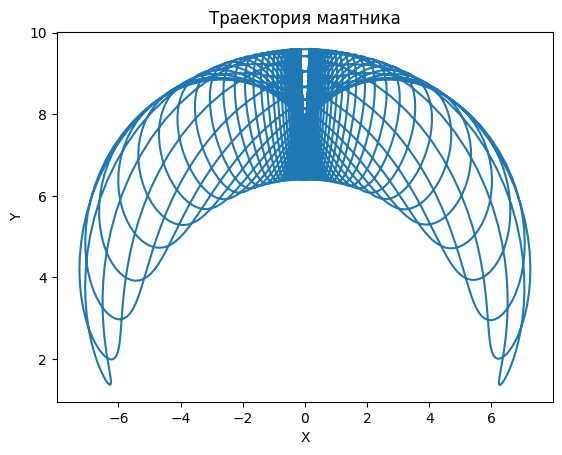

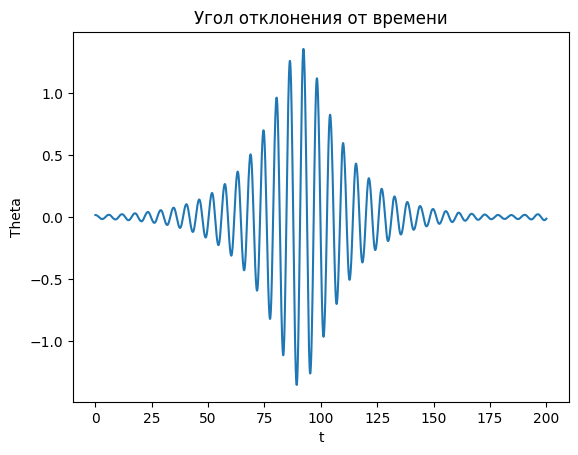

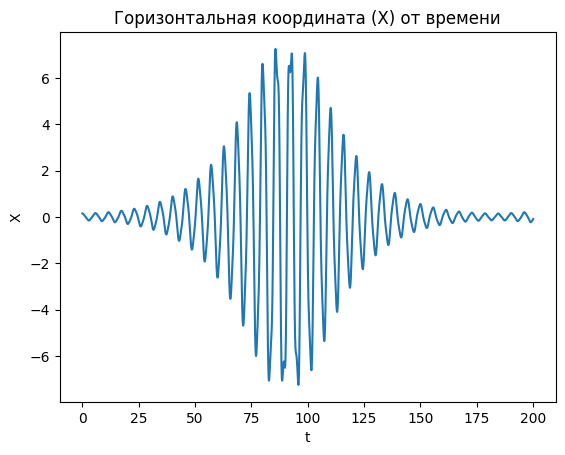

In [2]:
import numpy as np
import matplotlib.pyplot as plt

g = 9.81

l = 8
l1 = l/5

lambd = np.sqrt(g/l)*2

tau = 0.05

t_fin = 200

ts = np.linspace(tau,t_fin,int(t_fin/tau))

# Начнём с позиции максимального отклонения
theta0 = np.pi/200
omega0 = 0

thetas = [theta0]
omegas = [omega0]
xs = [(l+l1)*np.sin(theta0)]
ys = [(l+l1)*np.cos(theta0)]


for i,t in enumerate(ts[:-1]):

    # Дискретизируем диффуры с помощью разностной схемы первого порядка и выражаем 
    # угол и частоту (можем это сделать, так как используем явную схему Эйлера для углов,
    # А потом найденный угол подставляем в формулу для частоты)
    theta = thetas[i]+omegas[i]*tau
    thetas.append(theta)

    omega = omegas[i] - tau*g*np.sin(thetas[i+1])/(l+l1*np.cos(lambd*ts[i+1]))
    omegas.append(omega)

    xs.append((l+l1*np.cos(lambd*ts[i+1]))*np.sin(theta))
    ys.append((l+l1*np.cos(lambd*ts[i+1]))*np.cos(theta))


plt.plot(xs,ys)
plt.title("Траектория маятника")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

plt.plot(ts,thetas)
plt.title("Угол отклонения от времени")
plt.xlabel("t")
plt.ylabel("Theta")
plt.show()

plt.plot(ts,xs)
plt.title("Горизонтальная координата (X) от времени")
plt.xlabel("t")
plt.ylabel("X")
plt.show()


Наблюдаем увеличение амплитуды маятника, как и на картинке в учебнике.

Построим в фазовом пространстве области резонанса

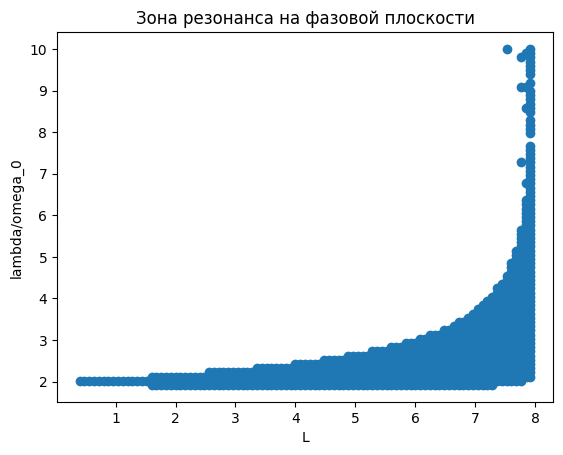

In [ ]:
# Границы области
lmbd_arr = np.linspace(0,np.sqrt(g/l)*10,100)
l1_arr = np.linspace(0,l*0.99,100)

lmbd_res = []
l1_res = []

# Итерируемся по лямбдам и L1
for lambd_i in lmbd_arr:
    for l1_i in l1_arr:
        thetas = [theta0]
        omegas = [omega0]
        xs = [(l+l1)*np.sin(theta0)]
        ys = [(l+l1)*np.cos(theta0)]


        for i,t in enumerate(ts[:-1]):

            theta = thetas[i]+omegas[i]*tau
            thetas.append(theta)

            omega = omegas[i] - tau*g*np.sin(thetas[i+1])/(l+l1_i*np.cos(lambd_i*ts[i+1]))
            omegas.append(omega)

            xs.append((l+l1_i*np.cos(lambd_i*ts[i+1]))*np.sin(theta))
        
        # Если в какой-то момент амплитуда была в 5 раз больше начального 
        # отклонения - считаем, что резонанс
        if max(np.abs(xs)) >= xs[0]*5:
            lmbd_res.append(lambd_i)
            l1_res.append(l1_i)

plt.scatter(x = l1_res, y = lmbd_res/np.sqrt(g/l))
plt.title("Зона резонанса на фазовой плоскости")
plt.xlabel("L")
plt.ylabel("lambda/omega_0")
plt.show()


## **Задание 2** (6.4 - пространственный осциллятор)

Обезразмерим уравнение с помощью $x_0 = \sqrt{\dfrac{\hbar}{m \omega_h}} = \sqrt{\dfrac{c\hbar}{e H}}$ и $V_0 = \omega_h x_0 = \sqrt{\dfrac{eHh}{m^2c}}$

Тогда система уравнений преобразуется к виду:  $$\dfrac{dV_x/dt}{V_0^2/x_0} = - \dfrac{\omega_x^2 x}{V_0^2/x_0}+\dfrac{\omega_h V_y}{V_0^2/x_0}$$  $$\dfrac{dV_y/dt}{V_0^2/x_0} = - \dfrac{\omega_y^2 y}{V_0^2/x_0}-\dfrac{\omega_h V_x}{V_0^2/x_0}$$ $$\dfrac{dV_z/dt}{V_0^2/x_0} = - \dfrac{\omega_z^2 z}{V_0^2/x_0}$$ $$\dfrac{dx/dt}{V_0} = \dfrac{V_x}{V_0}$$ $$\dfrac{dy/dt}{V_0} = \dfrac{V_y}{V_0}$$ $$\dfrac{dz/dt}{V_0} = \dfrac{V_z}{V_0}$$

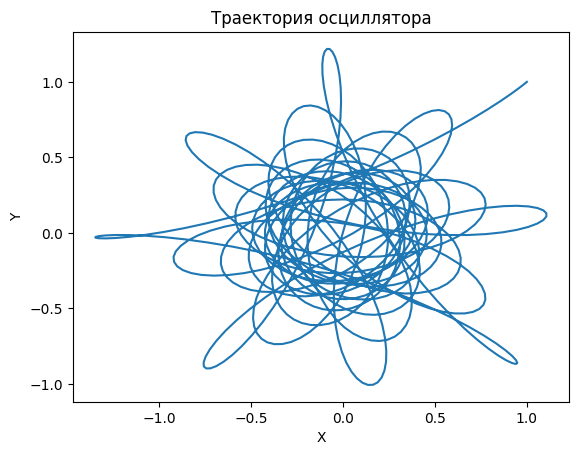

In [27]:
tau = 0.01

t_fin = 10

ts = np.linspace(tau,t_fin,int(t_fin/tau))
 
alpha = 0.5
H = 0.01

e = 1.6*10**(-19)
m = 9.1*10**(-31)
c = 3*10**8
h = 1.05*10**(-34)

wh = e*H/(m*c)

w0 = e*H/(m*c)*2

wx = wy = wz = w0

x_0 = np.sqrt(c*h/(e*H))
V_0 = np.sqrt(e*H*h/(m**2 * c))

x0 = x_0
y0 = x_0
z0 = 0

vx0 = vy0 = vz0 = 0

xs = [x0/x_0]
ys = [y0/x_0]
zs = [z0/x_0]
vxs = [vx0/V_0]
vys = [vy0/V_0]
vzs = [vz0/V_0]


for i,t in enumerate(ts[:-1]):

    # Дискретизируем диффуры (где учтём диссипацию энергии по формуле Рэлея из учебника) 
    # с помощью разностной схемы первого порядка и выражаем скорости и координаты
    vx = vxs[i]+tau*(-wx**2*xs[i]*x_0/V_0+wh*vys[i]-alpha*vxs[i])
    vxs.append(vx)
    vy = vys[i]+tau*(-wy**2*ys[i]*x_0/V_0-wh*vxs[i]-alpha*vys[i])
    vys.append(vy)
    vz = vzs[i]+tau*(-wz**2*zs[i]*x_0/V_0)
    vzs.append(vz)

    x = xs[i]+tau*V_0/x_0*vxs[i+1]
    xs.append(x)
    y = ys[i]+tau*V_0/x_0*vys[i+1]
    ys.append(y)
    z = zs[i]+tau*V_0/x_0*vzs[i+1]
    zs.append(z)    


plt.plot(xs,ys)
plt.title("Траектория осциллятора")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

Построим траектории для различных $\omega_h$ (то есть при различных $H$ - напряжённостях магнитного поля)

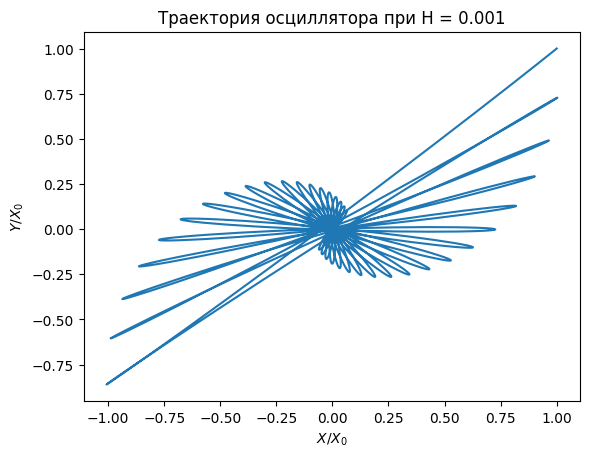

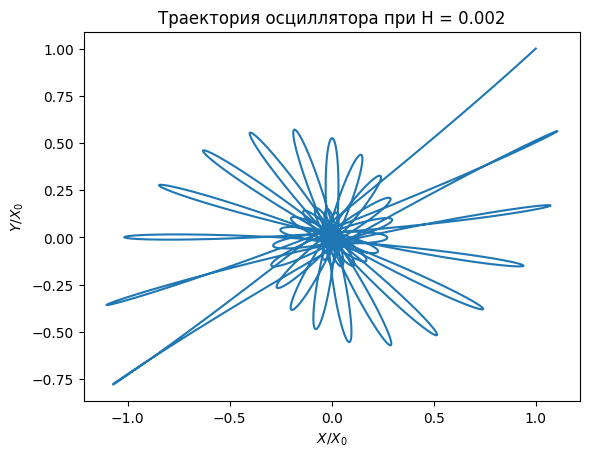

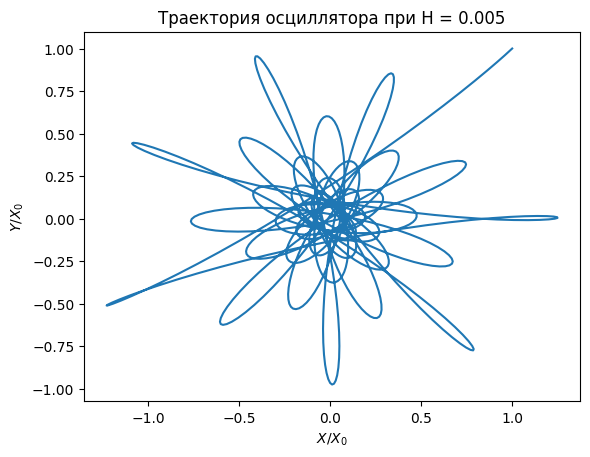

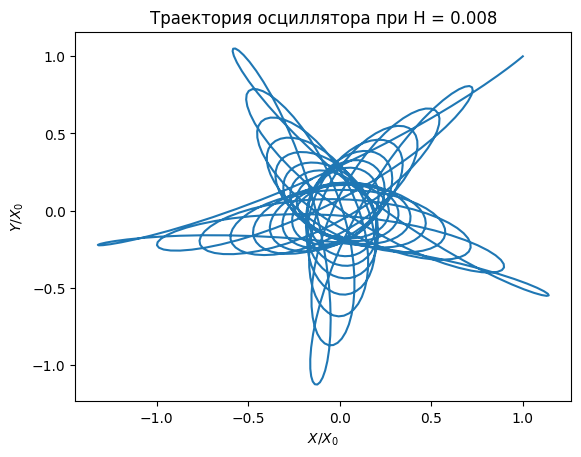

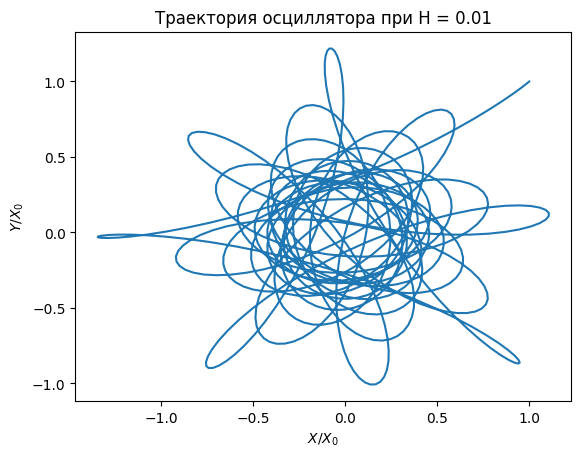

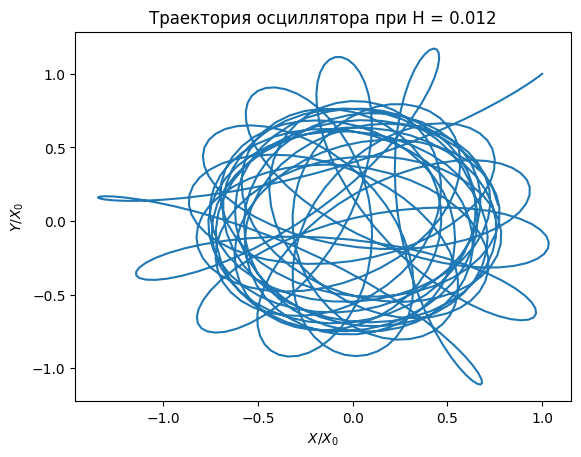

In [35]:
Hs = [0.001, 0.002, 0.005, 0.008, 0.01, 0.012]

for H in Hs:
    wh = e*H/(m*c)

    x_0 = np.sqrt(c*h/(e*H))
    V_0 = np.sqrt(e*H*h/(m**2 * c))

    x0 = x_0
    y0 = x_0
    z0 = 0

    vx0 = vy0 = vz0 = 0

    xs = [x0/x_0]
    ys = [y0/x_0]
    zs = [z0/x_0]
    vxs = [vx0/V_0]
    vys = [vy0/V_0]
    vzs = [vz0/V_0]


    for i,t in enumerate(ts[:-1]):

        # Дискретизируем диффуры (где учтём диссипацию энергии по формуле Рэлея из учебника) 
        # с помощью разностной схемы первого порядка и выражаем скорости и координаты
        vx = vxs[i]+tau*(-wx**2*xs[i]*x_0/V_0+wh*vys[i]-alpha*vxs[i])
        vxs.append(vx)
        vy = vys[i]+tau*(-wy**2*ys[i]*x_0/V_0-wh*vxs[i]-alpha*vys[i])
        vys.append(vy)
        vz = vzs[i]+tau*(-wz**2*zs[i]*x_0/V_0)
        vzs.append(vz)

        x = xs[i]+tau*V_0/x_0*vxs[i+1]
        xs.append(x)
        y = ys[i]+tau*V_0/x_0*vys[i+1]
        ys.append(y)
        z = zs[i]+tau*V_0/x_0*vzs[i+1]
        zs.append(z)    


    plt.plot(xs,ys)
    plt.title(f"Траектория осциллятора при H = {H}")
    plt.xlabel(r"$X/X_0$")
    plt.ylabel(r"$Y/X_0$")
    plt.show()